# Aarhus Universitet &mdash; SWMAL E25  
## Assignment O1  
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | PEEPEE       |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**12/09-2025**

# L02 - Cost function

# L02 - Dummy Classifier

# L02 - Performance Metrics

## Performance Metrics

#### Qa Implement the Accuracy function and test it on the MNIST data.

We now follow the convention in Scikit-learn, that a score funtion takes the arguments `y_true` and then `y_pred`

```
    sklearn.metrics.accuracy_score(y_true, y_pred, ..)
```

Implement a general accuracy function `MyAccuracy(y_true, y_pred)`. Again, implement the function you self from scratch, i.e. do not use any helper functions from Scikit-learn (implementing via `sklearn.metrics.confusion_matrix` is also not allowed, othewise you will then learn nothing!)

Reuse your MNIST data loader and test the `MyAccuracy` function  both on your dummy classifier and on the Stochastic Gradient Descent classifier (with setup parameters as in [HOML]).

Remember to use the '5/not-5' ground-truth data, ala

```python
    y_train_5 = (y_train == '5')    
    y_test_5  = (y_test == '5')
```

not the full 10 class MNIST output categories, since we are dealing with metrics handling only pure binary classifiers (well, there is a way to deal with this using micro/macro averaging of multiclass classifiers, you meet these in the gridsearch exercise later).

Compare your accuracy score with the acutal value from `sklearn.metrics.accuracy_score()`.

(Implementation note: what do you do, if the denominator is zero?)

The actual value of X[0]: 5


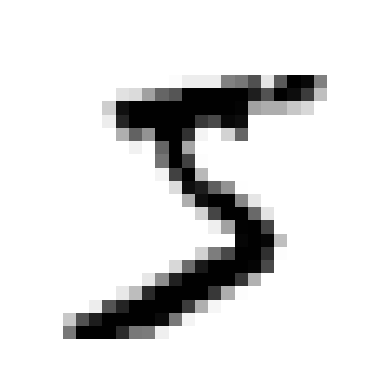

In [ ]:
# MNIST Data loader
# TODO: Fix daniels løsning her

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784',return_X_y=True, as_frame=False) # Returns (data, target)
    
y_true, y_pred = MNIST_GetDataSet()
print(f'The actual value of X[0]: {y[0]}')

def MNIST_PlotDigit(data):
    image = data.reshape(28,28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")

MNIST_PlotDigit(X[0])
plt.show()

An accuracy function implemented in pure python to calculate the accuracy of an algorithm. This function calculates the True Positives, True Negatives, False Positives and False Negatives.
The accuracy is calculated by dividing the sum of True Positive and True Negative with the total.

$\frac{(\sum TP + \sum TN)}{\sum Total}$

In [ ]:
import math
from sklearn.metrics import accuracy_score


def MyAccuracy(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
            else:
                TN += 1
        else:
            if y_true[index] == True:
                FN += 1
            else:
                FP += 1

    sum_true = TP + TN
    sum = TP + FP + TN + FN

    return sum_true / sum
    
def TestAccuracy(y_true, y_pred):
    a0 = MyAccuracy(y_true, y_pred)
    a1 = accuracy_score(y_true, y_pred)

    print(f"\nmy a          ={a0}")
    print(f"scikit-learn a={a1}")

    if math.isclose(a0, a1, rel_tol=1e-9, abs_tol=1e-12):
        print("Results is perfect lesgoooo")
    else:
        print("Results is not good bro")

# TODO: ENABLE THIS
# TestAccuracy(y_true, y_pred)

#### Qb Implement Precision, Recall and $F_1$-score and test it on the MNIST data for both the SGD and Dummy classifier models


The implementation if Precision, Recall and $F_1$-score.
The 3 functions is calculated as seen in Nomenclature for the confusion matrix in MAL lection 2

Precision:
$p = \frac{TP}{TP+FP}$

Recall:
$r=\frac{TP}{TP+FN}$

$F_1$-score:
$F_1=\frac{2pr}{p+r}$

In [ ]:
def MyPrecision(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == False:
                FP += 1

    sum = TP + FP

    if not sum:
        return 0

    # Accuracy
    return  TP / sum

def MyRecall(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == True:
                FN += 1

    sum = TP + FN

    if not sum:
        return 0

    # Accuracy
    return  TP / sum
    
def MyF1Score(y_true, y_pred):
    precision = MyPrecision(y_true, y_pred)
    recall = MyRecall(y_true, y_pred)

    sum = precision + recall

    if not sum:
        return 0
    
    return 2 * (recall * precision) / sum

# TODO: your test code here!


NameError: name 'MINST' is not defined

#### Qc The Confusion Matrix

Revisit your solution to Qb in the `dummy_classifier.ipynb`. Generate the confusion matrix for both the Dummy and the SGD classifier using the `scklearn.metrics.confusion_matrix` function. 

I got the two confusion matrices

```
M_dummy=[[18166     0]
        [ 1834     0]]
   
M_SDG=[[17618   548]
      [  267  1567]]

```
your data may look similar (but not 100% equal).

How are the Scikit-learn confusion matrix organized, where are the TP, FP, FN and TN located in the matrix indices, and what happens if you mess up the parameters calling

```python
confusion_matrix(y_test_5_pred, y_test5)
```

instead of 
```python
confusion_matrix(y_test_5, y_test_5_pred)
```

In [ ]:
from sklearn.metrics import confusion_matrix

M_dummy = confusion_matrix() # TODO: Tilføj y_test_5 og y_pred_dummy
M_SDG = confusion_matrix() # TODO: Tilføj y_test_5 og y_pred_sgd

print("Confusion matrix for dummy")
print(M_dummy)

print()

print("Confusion matrix for SGD")
print(M_SDG)

# TODO: Lav billeder af TP, FP, FN og TN

#### Qd A Confusion Matrix Heat-map

In [ ]:
plt.matshow(M_dummy, cmap=plt.cm.gray)
plt.show()

plt.matshow(M_SDG, cmap=plt.cm.gray)
plt.show()

### Qe Conclusion

This exercise have us a better understanding of how to measure the performance of machine learning algorithms and how to implement it in Python. By working further with the MNIST dataset, we learned more about the Scikit package and how to work with the different metrics like accuracy, precision, recall and F1-score.

## Implementing a dummy binary-classifier with fit-predict interface

#### Qa  Load and display the MNIST data

The MNIST database consists of handwritten digits and has a training set of 60,000 examples. It’s retrieved from openml.org, and each digit in the dataset is a 28x28-pixel image.

The value of X[0] is: 5


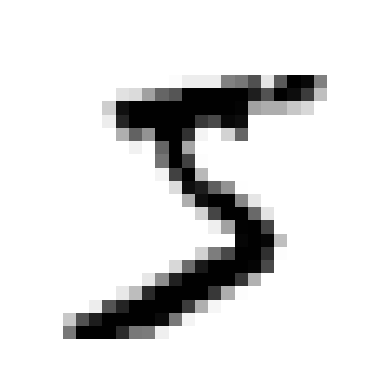

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784', return_X_y=True, as_frame=False)

def MNIST_PlotDigit(data):
    import matplotlib
    import matplotlib.pyplot as plt
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")
    plt.show()


X, y = MNIST_GetDataSet()
print(f'The value of X[0] is: {y[0]}')
MNIST_PlotDigit(X[0])

The return_X_y parameter makes fetch_openml return a tuple (data, target) instead of a Bunch container, which otherwise contains more information about the dataset.
Once the dataset is retrieved, a single digit can be displayed with the MNIST_PlotDigit(data) function.

From the output above, you can see that the value of X[0] is 5 and the plot shows the handwritten digit located in that position.

#### Qb  Add a Stochastic Gradient Decent [SGD] Classifier

The dataset is split into a training and a test part so that testing and training aren’t done on exactly the same data, and an SGD Classifier is used to train the model on the data in the training part. This implementation can be seen below:

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.linear_model import SGDClassifier

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

shuffle_idx = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)


SGDClassifier(random_state=42)

Next, a true positive (a correctly classified digit), a false positive (a digit the model thinks is a 5 but is actually something else), and finally a true negative (a number correctly not classified as 5) are identified. The implementation is shown below.

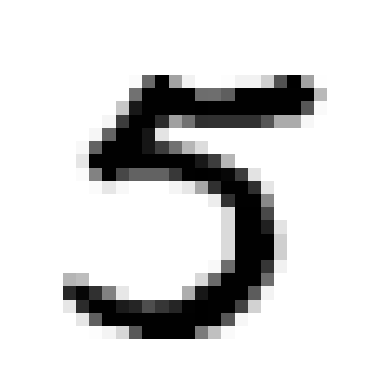

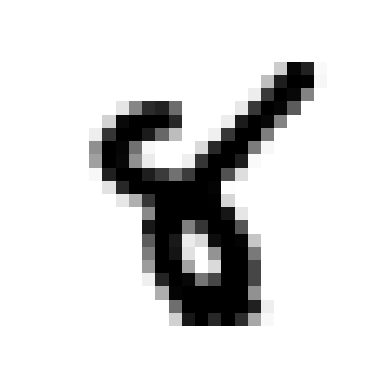

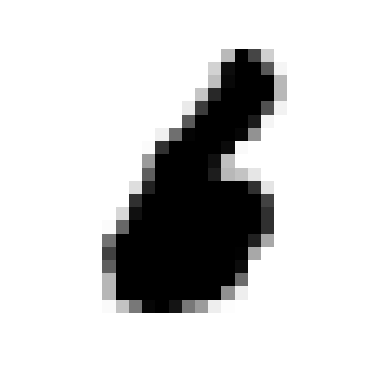

In [ ]:
import numpy as np

# Predict labels
y_test_pred = sgd_clf.predict(X_test)

# Random true positive
true_pos_idx = np.where((y_test_5 == True) & (y_test_pred == True))[0]
rand_true_pos = np.random.choice(true_pos_idx)

# Random false positive
false_pos_idx = np.where((y_test_5 == False) & (y_test_pred == True))[0]
rand_false_pos = np.random.choice(false_pos_idx)

# Random true negative
true_neg_idx = np.where((y_test_5 == False) & (y_test_pred == False))[0]
rand_true_neg = np.random.choice(true_neg_idx)

# Plot a digit
MNIST_PlotDigit(X_test[rand_true_pos])
MNIST_PlotDigit(X_test[rand_false_pos])
MNIST_PlotDigit(X_test[rand_true_neg])


The first picture is the true positive, the second is the false positive and the final is the true negative. This clearly visualizes how the model performs and where it makes mistakes.

#### Qc Implement a dummy binary classifier

Below is the implementation of a dummy classifier, which consists of a fit and a predict method. The dummy classifier only returns zeros when the predict function is used.

In [ ]:
from sklearn.base import BaseEstimator

class DummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X),), dtype=bool)

In [ ]:
from sklearn.metrics import accuracy_score

dummy = DummyClassifier()

dummy.fit(X_train, y_train_5)
y_dummy_pred = dummy.predict(X_test)
print(f"{y_dummy_pred}")

dummy_accuracy = accuracy_score(y_test_5, y_dummy_pred)
print(f"score for DummyClassifier: {dummy_accuracy:.2%}")

[False False False ... False False False]
score for DummyClassifier: 91.08%


### Qd Conclusion

The exercise provides a good understanding of how an estimator is used and how you can create your own classifier using BaseEstimator from the scikit-learn library. It also showed that it’s possible to create an estimator that doesn’t actually work (DummyClassifier) but still produces good results. It’s also very important to split your dataset so you don’t end up training and testing on the same chunk of data.

#### Qa Given the following $\mathbf{x}^{(i)}$'s, construct and print the $\mathbf X$ matrix in python.

$$
    \ar{rl}{
      \bx\pown{1} &= \ac{c}{ 1\\ 2\\ 3} \\
      \bx\pown{2} &= \ac{c}{ 4\\ 2\\ 1} \\
      \bx\pown{3} &= \ac{c}{ 3\\ 8\\ 5} \\
      \bx\pown{4} &= \ac{c}{-9\\-1\\ 0}
    }
$$

To define the above matrix in python, we utilize the `np.array` function in `numpy` to define the values as a list of lists for each row in the matrix.

In [ ]:
import numpy as np

y_true = np.array([1,2,3,4]) # NOTE:  you'll need this later

X = np.array([
    [1, 2, 3],
    [4, 2, 1],
    [3, 8, 5],
    [-9, -1, 0]
])

print(X)

[[ 1  2  3]
 [ 4  2  1]
 [ 3  8  5]
 [-9 -1  0]]


#### Qb Implement the $\norm{1}$ and $\norm{2}$ norms for vectors in python.

Implementatin of L1- and L2 norms in pure python.


In [ ]:
import math
def L1(vector):
    if vector.ndim != 1:
        raise ValueError("Input should be a 1D vector")
    sum = 0.0
    for i in range(len(vector)):
        sum += (vector[i]**2)**0.5

    return sum

def L2(vector):
    if vector.ndim != 1:
        raise ValueError("Input should be a 1D vector")
    
    sum = 0.0
    for i in range(len(vector)):
        sum += vector[i]**2
    return sum ** 0.5

def L2Dot(vector):
    return np.dot(vector.T,vector)**0.5

# TEST vectors: here I test your implementation...calling your L1() and L2() functions
tx=np.array([1, 2, 3, -1])
ty=np.array([3,-1, 4,  1])

expected_d1=8.0
expected_d2=4.242640687119285

d1=L1(tx-ty)
d2=L2(tx-ty)

print(f"tx-ty={tx-ty}, d1-expected_d1={d1-expected_d1}, d2-expected_d2={d2-expected_d2}")

eps=1E-9 
assert math.fabs(d1-expected_d1)<eps, "L1 dist seems to be wrong" 
assert math.fabs(d2-expected_d2)<eps, "L2 dist seems to be wrong" 

print("OK(part-1)")

d2dot=L2Dot(tx-ty)
print("d2dot-expected_d2=",d2dot-expected_d2)
assert math.fabs(d2dot-expected_d2)<eps, "L2Ddot dist seem to be wrong" 
print("OK(part-2)")

tx-ty=[-2  3 -1 -2], d1-expected_d1=0.0, d2-expected_d2=0.0
OK(part-1)
d2dot-expected_d2= 0.0
OK(part-2)


The functions return a difference of `0.0`, which means that the implementation is correct according to the test.

### Qc Construct the Root Mean Square Error (RMSE) function (Equation 2-1 [HOML]).

RMSE is used to se the difference between the predicted values and therefore the performance of the model that we are testing. The RMSE function always returns a non-negative number. The lower the number, the better the model fits the data. If its 0 the models predictions are exact.

The number can be as high as our `y_true` values.

In the code below the prediceted values are made with the `h(X)`function.

In [ ]:
from math import fabs

# Dummy h function:
def h(X):    
    if X.ndim!=2:
        raise ValueError("excpeted X to be of ndim=2, got ndim=",X.ndim)
    if X.shape[0]==0 or X.shape[1]==0:
        raise ValueError("X got zero data along the 0/1 axis, cannot continue")
    return X[:,0]

def RMSE(X, y):
    if X.shape != y.shape:
        raise ValueError(f"X shape ({X.shape}) should be the same as y ({y.shape})")

    return L2(X-y) / np.sqrt(len(y))


# Calls your RMSE() function:
r=RMSE(h(X), y_true)

# TEST vector:
eps=1E-9
expected=6.57647321898295
print(f"RMSE={r}, diff={r-expected}")
assert fabs(r-expected)<eps, "your RMSE dist seems to be wrong" 

print("OK")

RMSE=6.576473218982953, diff=2.6645352591003757e-15
OK


#### Qd Similar construct the Mean Absolute Error (MAE) function (Equation 2-2 [HOML]) and evaluate it.

Implementation of the MAE equation:

$\text{MAE}(\mathbf{X}, h) = \frac{1}{m} \sum_{i=1}^{m} \left| h\!\left(\mathbf{x}^{(i)}\right) - y^{(i)} \right|$

In [ ]:
def MAE(X, y):
    if X.shape != y.shape:
        raise ValueError(f"X shape ({X.shape}) should be the same as y ({y.shape})")
    return L1(X - y) / len(y)

# Calls your MAE function:
r=MAE(h(X), y_true)

# TEST vector:
expected=3.75
print(f"MAE={r}, diff={r-expected}")
assert fabs(r-expected)<eps, "MAE dist seems to be wrong" 

print("OK")

MAE=3.75, diff=0.0
OK


The MAE is 3.75 which gives us a difference of 0.0.

#### Qe Robust Code 

In our functions, we have made them more robust by adding error handling, such as using `ndim`, `ValueError` and `shape` to check if the parameters passed to the function is a vector or if it has the shape that we expect.

By doint the exercises on cost function a deeper understanding of the concepts are achieved.
It has also proven a good foundating in the python way of doing Machine Learning. By using the `fail fast` method, its possible to save much time not spending time on uneccesary computations that eventually would end in an error cased by wrong data or shape.

Its also very keen to be reusing robust code in Machine Learning. By having a collection of small, effective and safe code that can be referenced in the furture, is something to be appreciated.